In [1]:
import glob
import os

from natsort import natsorted
from pprint import pprint
from tqdm import tqdm

import numpy as np
import tifffile as tiff

from lib.visualization import plot_traces
from lib.visualization import show_one_image

In [ ]:
base_dir = "/home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/"
data_type = "003 2P-V1"
mouse_id = "A455"
mouse_path = os.path.join(base_dir, data_type, mouse_id)
print(mouse_path)
os.path.exists(mouse_path)
session_path = natsorted(glob.glob(os.path.join(mouse_path, "2026*")))
# pprint(session_path)
date_ls = [os.path.basename(s) for s in session_path]

/home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 2P-V1/A455
['/home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 '
 '2P-V1/A455/20260316',
 '/home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 '
 '2P-V1/A455/20260317',
 '/home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 '
 '2P-V1/A455/20260318',
 '/home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 '
 '2P-V1/A455/20260319',
 '/home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 '
 '2P-V1/A455/20260320',
 '/home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 '
 '2P-V1/A455/20260323',
 '/home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 '
 '2P-V1/A455/20260324',
 '/home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 '
 '2P-V1/A455/20260325',
 '/home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 '
 '2P-V1/A455/20260326',
 '/home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 '
 '2P-V1

In [17]:
# specify the date of the session to process
date = '20260325'
if date not in date_ls:
    raise ValueError(f"Date {date} not found in session_path.")

# select the folder with name end with the date
session_folder = [s for s in session_path if s.endswith(date)][0]
print(f"Session folder: {session_folder}")

# # select which session to process
# session_folder = session_path[6]
# print(f"Session folder: {session_folder}")

Session folder: /home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 2P-V1/A455/20260325


In [18]:
suite2p_folder = os.path.join(session_folder, "suite2p")
if not os.path.exists(suite2p_folder):
    print(f"Suite2p folder does not exist: {suite2p_folder}")
    os.makedirs(suite2p_folder)

raw_folder = glob.glob(os.path.join(session_folder, "TSeries-*"))
if not(len(raw_folder) == 1):
    print(f"Expected exactly one raw data folder, but found {len(raw_folder)}")
print(f"Raw data folder: {raw_folder[0]}")

Suite2p folder does not exist: /home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 2P-V1/A455/20260325/suite2p
Expected exactly one raw data folder, but found 2
Raw data folder: /home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 2P-V1/A455/20260325/TSeries-03252026-1138-001


In [19]:
# get parameters of imaging data from the xml file in the raw data folder
from lib.input_output import get_parameters

imaging_parameters = get_parameters(raw_folder[0])

plane_num = imaging_parameters['plane_num']
print(f'detected plane_num: {plane_num}')

plane_ls = list(range(plane_num))
print(f'set plane_ls: {plane_ls}')

channel_ls = imaging_parameters['channel_ls'] # recorded channels
print(f'detected channel_ls: {channel_ls}')

frame_size = (int(imaging_parameters['pixelsPerLine']),
    int(imaging_parameters['linesPerFrame']))
print(f'detected frame_size: {frame_size}')

frame_rate = imaging_parameters['frame_rate']
print(f'detected frame_rate: {frame_rate}')

detected plane_num: 1
set plane_ls: [0]
detected channel_ls: [1, 2]
detected frame_size: (512, 512)
detected frame_rate: 9.957911294647365


# Run the suite2p pipeline

Make ops

In [20]:
import suite2p
from suite2p.io import ome_to_binary
ops = suite2p.default_ops()

ops['anatomical_only'] = 0
ops['baseline'] = 'maximin'
ops['bidiphase'] = 0
ops['bruker'] = True
ops['combined'] = False
ops['data_path'] = raw_folder

ops['do_bidiphase'] = True
ops['fs'] = frame_rate
ops['functional_chan'] = 2
ops['high_pass'] = 100
ops['input_format'] = 'bruker'
ops['max_overlap'] = 1.0
ops['nbinned'] = 5000

ops['preclassify'] = 0
ops['reg_tif'] = False
ops['reg_tif_chan2'] = False
ops['save_path0'] = session_folder
ops['sig_baseline'] = 30

ops['tau'] = 1.3

ops['win_baseline'] = 180

# Main settings
ops['multiplane_parallel'] = True
ops['nchannels'] = len(channel_ls)
ops['nplanes'] = len(plane_ls)

# File input/output settings
# ops['save_folder'] = suite2p_folder # seems not work for `ome_to_binary`

# Registration settings
# ops['align_by_chan'] = 2 # as the anatomical channel saved in the second channel
ops['do_registration'] = True
ops['keep_movie_raw'] = False # Whether to keep binary file of non-registered frames.
ops['maxregshift'] = 0.1 # in fraction of frame size
ops['nimg_init'] = 1000 # how many frames to use to compute reference image for registration
# ops['nonrigid'] = True
ops['two_step_registration'] = True # whether or not to run registration twice 

pprint(ops)

{'1Preg': False,
 'align_by_chan': 1,
 'allow_overlap': False,
 'anatomical_only': 0,
 'aspect': 1.0,
 'baseline': 'maximin',
 'batch_size': 500,
 'bidi_corrected': False,
 'bidiphase': 0,
 'block_size': [128, 128],
 'bruker': True,
 'bruker_bidirectional': False,
 'cellprob_threshold': 0.0,
 'chan2_thres': 0.65,
 'classifier_path': '',
 'combined': False,
 'connected': True,
 'data_path': ['/home/wrx/Data_attention/Transfer '
               'learning/LinShu/DATA_linshu/003 '
               '2P-V1/A455/20260325/TSeries-03252026-1138-001',
               '/home/wrx/Data_attention/Transfer '
               'learning/LinShu/DATA_linshu/003 '
               '2P-V1/A455/20260325/TSeries-03252026-1138-005'],
 'delete_bin': False,
 'denoise': False,
 'diameter': 0,
 'do_bidiphase': True,
 'do_registration': True,
 'fast_disk': [],
 'flow_threshold': 1.5,
 'force_refImg': False,
 'force_sktiff': False,
 'frames_include': -1,
 'fs': 9.957911294647365,
 'functional_chan': 2,
 'h5py': [],
 'h5py_

Registration

In [21]:
# # Get the frame number of each plane for each stimulus.

# folder_name = os.path.basename(raw_folder[0])
# file_filter = '{}_Cycle00001_Ch2_*.ome.tif'.format(folder_name)
# n_frames = len(glob.glob('{}/{}'.format(raw_folder[0], file_filter)))
# print(f'n_frames: {n_frames}')
# # save the frame number of each plane for each stimulus to ops
# ops['n_frames'] = n_frames
# np.save(os.path.join(suite2p_folder, 'ops.npy'), ops)

In [22]:
plane_folder = os.path.join(suite2p_folder, 'plane0')
f_data_path = os.path.join(plane_folder, 'data.bin')
if os.path.exists(f_data_path):
    print(f"Data already converted to binary format at: {f_data_path}")
else:
    print(f"Converting data to binary format at: {f_data_path}")
    ops0 = ome_to_binary(ops=ops) # convert all the planes together

Converting data to binary format at: /home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/003 2P-V1/A455/20260325/suite2p/plane0/data.bin
bruker
** Found 33080 tifs - converting to binary **
nchannels = 2


In [23]:
f_data = suite2p.io.BinaryFile(Ly=frame_size[1], Lx=frame_size[0],
    filename=f_data_path)
registration_outputs = suite2p.registration_wrapper(f_data, ops=ops)

NOTE: estimated bidiphase offset from data: 0 pixels
Reference frame, 64.05 sec.
Registered 500/16540 in 9.00s
Registered 1000/16540 in 18.92s
Registered 1500/16540 in 28.73s
Registered 2000/16540 in 37.98s
Registered 2500/16540 in 47.90s
Registered 3000/16540 in 61.03s
Registered 3500/16540 in 70.73s
Registered 4000/16540 in 80.54s
Registered 4500/16540 in 90.38s
Registered 5000/16540 in 99.55s
Registered 5500/16540 in 109.32s
Registered 6000/16540 in 122.60s
Registered 6500/16540 in 134.63s
Registered 7000/16540 in 144.30s
Registered 7500/16540 in 153.67s
Registered 8000/16540 in 162.75s
Registered 8500/16540 in 171.84s
Registered 9000/16540 in 181.18s
Registered 9500/16540 in 192.11s
Registered 10000/16540 in 203.57s
Registered 10500/16540 in 212.70s
Registered 11000/16540 in 221.71s
Registered 11500/16540 in 230.74s
Registered 12000/16540 in 241.75s
Registered 12500/16540 in 250.68s
Registered 13000/16540 in 259.89s
Registered 13500/16540 in 273.43s
Registered 14000/16540 in 283.45

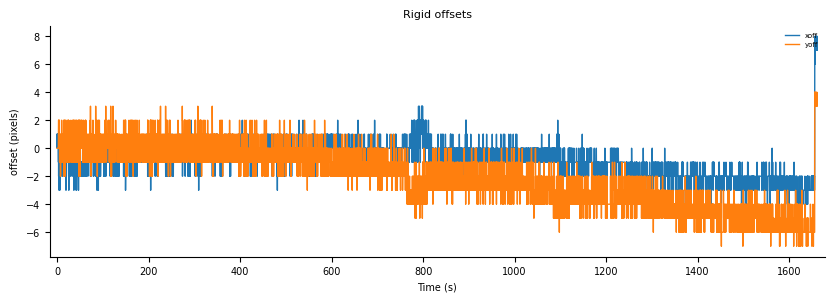

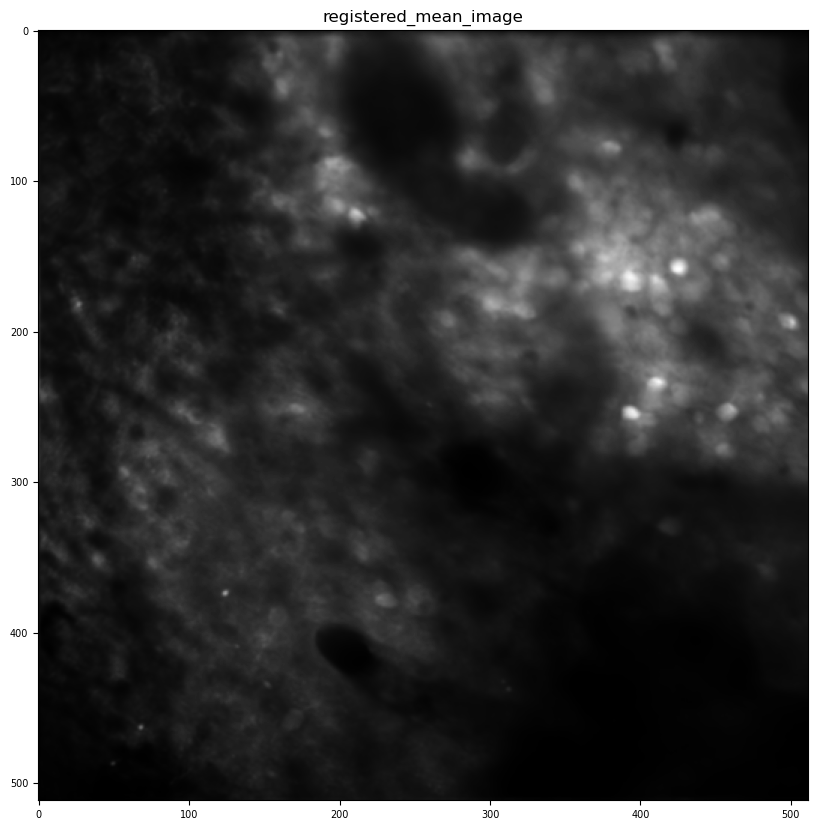

In [24]:
(refImg, rmin, rmax, meanImg, rigid_offsets, nonrigid_offsets, zest,
meanImg_chan2, badframes, yrange, xrange) = registration_outputs

np.save(os.path.join(plane_folder, 'rigid_offsets.npy'),
    np.array(rigid_offsets))

yoff, xoff, corrXY = rigid_offsets
offset = np.vstack((xoff, yoff)).T
plot_traces(offset, data_rate=frame_rate,
    labels=['xoff', 'yoff'], figsize=(10, 3), ylabel='offset (pixels)',
    title='Rigid offsets')

show_one_image(meanImg, figsize=(10, 10), title = "registered_mean_image")
tiff.imwrite(os.path.join(plane_folder, 'meanImg.tif'),
    meanImg.astype(np.int16))

In [25]:
# Calculate the Mean and STD projection images across frames and save
f_reg_path = os.path.join(plane_folder, 'data.bin')
f_reg = suite2p.io.BinaryFile(Ly=frame_size[1], Lx=frame_size[0],
    filename=f_reg_path)
print('shape of f_reg:', f_reg.shape)

# from <class 'suite2p.io.binary.BinaryFile'> to <class 'numpy.memmap'>
f_reg = f_reg[:]

# to save disk space, not save the registered movie as tiff file
# movie_path = os.path.join(plane_folder, 'reg.tif')
# print('Writing to tiff file: {}'.format(movie_path))
# tiff.imwrite(movie_path, movie_list[stim])

mean_projection = np.mean(f_reg, axis=0)
tiff.imwrite(os.path.join(plane_folder, 'mean_projection.tif'),
    mean_projection.astype(np.int16))
std_projection = np.std(f_reg, axis=0)
tiff.imwrite(os.path.join(plane_folder, 'std_projection.tif'),
    std_projection.astype(np.int16))

shape of f_reg: (16540, 512, 512)
